# **DECISION TREE**
Decision tree learning is a machine learning technique that creates a tree-structured graph called a decision tree. In the field of machine learning, the learning technique is also simply called a "decision tree." It can be used for both classification and regression, and in the case of classification, it is possible to perform multi-class classification of three or more classes. Here, we will only deal with basic classification.

A decision tree is a tree-structured graph that can assign data represented by attribute - value pairs {attribute 1: value 1, attribute 2: value 2, attribute 3: value 3, ..., attribute n: value n} to a class by repeating conditional branching. In the field of machine learning, "attributes and values" refers to "feature names and feature values." From here on, we will simply call them features.

Each circled element is called a node. Nodes can be thought of as having a parent-child relationship; for example, node (0) is called the parent node of nodes (1), (2), and (3). Conversely, nodes (1), (2), and (3) are called child nodes of node (0) . The top node (0) is the root node, and the nodes that represent classification results such as (1), (4), (5), (7), (8), and (9) are called leaf nodes. The arrows for conditional branches are called edges. The number of edges from a node to the root node is its depth.

There are various ways to train decision trees, and we will look at one method by creating it from scratch. The decision trees created will differ depending on the learning method, hyperparameters, and training data.

In theory, decision trees can handle not only quantitative variables but also categorical variables. However, the scikit-learn implementation only supports quantitative variables, so we will create a scratch implementation in that way.

# Scratch Decision Tree
We will create a decision tree class for classification from scratch. We will implement the algorithm using only minimal libraries such as NumPy.

Decision tree learning involves a hyperparameter called the (maximum) depth, which indicates how many times a conditional branch is repeated, and implementation of a depth of 1 is a required task. A depth of 2 or more is an advanced task.

There are various ways to train the model, but here we will implement the CART method, which is also used in scikit-learn. In this method, the model is divided into two branches to reduce the complexity of training.

# Finding the division conditions through learning
Through learning, we determine what conditions should be used to divide nodes effectively.

To determine whether a node is well separated, we calculate the Gini impurity and information gain.
# Question 1: Function to calculate impurity
Create a function to calculate the Gini impurity of a node . The Gini impurity $I(t)$ for node $t$ is calculated using the following formula. The more mixed the classes are, the higher the Gini impurity.

$$I(t) = 1 - \sum_{i=1}^{K}P^2(C_i|t) = 1 - \sum_{i=1}^{K}(\frac{N_{t,i}}{N_{t,all}})^2$$

$t$ : Node index

$i$ : class index

$K$ : number of classes

$C_i$ : the i-th class

$P(C_i|t)$ : The proportion of $C_i$ at the t-th node

$N_{t,i}$ : The number of samples belonging to the i-th class in the t-th node

$N_{t,all}$ : the total number of samples in the t-th node

Start by creating a simple example and comparing the results of your calculations with those of the function.

"example"

Class 1: 15 samples, Class 2: 15 samples → Gini impurity 0.500
Class 1: 15 samples, Class 2: 15 samples, Class 3: 15 samples → Gini impurity 0.667
Class 1: 18 samples, Class 2: 12 samples → Gini impurity 0.480
Class 1: 30 samples, Class 2: 0 samples → Gini impurity 0.000

In [1]:
import numpy as np

class ScratchDecisionTreeClassifier:
    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

In [2]:
# Instantiate the class
tree = ScratchDecisionTreeClassifier()

# Example 1: [15, 15]
y1 = np.array([0]*15 + [1]*15)
print("Example 1 Gini:", tree._calc_gini(y1)) 

# Example 2: [15, 15, 15]
y2 = np.array([0]*15 + [1]*15 + [2]*15)
print("Example 2 Gini:", tree._calc_gini(y2))

# Example 3: [18, 12]
y3 = np.array([0]*18 + [1]*12)
print("Example 3 Gini:", tree._calc_gini(y3))

# Example 4: [30, 0]
y4 = np.array([0]*30)
print("Example 4 Gini:", tree._calc_gini(y4))

Example 1 Gini: [0.5]
Example 2 Gini: [0.66666667]
Example 3 Gini: [0.48]
Example 4 Gini: [0.]


# Question 2: Function to calculate information gain
Next, create a function to calculate the information gain between nodes . Call the function that calculates the Gini impurity $I(t)$ created in Problem 1 and use it. The information gain $IG$ is calculated using the following formula. The better the division, the greater the information gain.

Since there are only two branches here, the branches are called the "left node" and the "right node".

$$IG(p) = I(p) - \frac{N_{left,all}}{N_{p,all}}I(left) - \frac{N_{right,all}}{N_{p,all}}I(right)$$

$p$ : index of the parent node

$left$ : index of the left node

$right$ : index of the right node

Start by creating a simple example and comparing the results of your calculations with those of the function.

"example"

Left node class 1: 10 samples, left node class 2: 30 samples, right node class 1: 20 samples, right node class 2: 5 samples → information gain 0.143

In [3]:
import numpy as np

class ScratchDecisionTreeClassifier:
    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]

        gain_l = (len(labels_l) / len(y)) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / len(y)) * self._calc_gini(labels_r)

        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

In [4]:
# Create test data
X = np.array([[0]]*40 + [[1]]*25)  # Feature values
y = np.array([0]*10 + [1]*30 + [0]*20 + [1]*5)  # Class labels

# Create classifier and compute IG
tree = ScratchDecisionTreeClassifier()
gain = tree._calc_ig(X, feature_index=0, y=y, threshold=1)

print("Information Gain:", round(gain.item(), 3))

Information Gain: 0.143


# Problem 3: Learning
Create code to divide the space and generate a decision tree graph. Currently, the decision tree is of depth 1, so only one division is performed. Generating a graph here means finding the conditions for which features should be greater than or equal to a certain number for one division.

All combinations of splits are performed on the training data, and the split that maximizes the information gain between nodes is recorded as the splitting criterion for that node.

A node with an impurity of 0, where classes are not mixed, or a node at a specified depth, becomes a leaf node . The leaf node records the class, which is used as the classification class during estimation. If classes are not mixed, the class is recorded as is, and if classes are mixed, the class is determined by majority vote.

How to get the combination

The simplest way to get all combinations is to use the feature values ​​themselves as thresholds to split the data. This is the method to use for the scratch data on one side.

Another approach is to use the intermediate value as the threshold, which is what scikit-learn uses.

"supplement"

When using the function that calculates the information gain in problem 2 for problem 3, the impurity $I(p)$ of the parent node is fixed, so the same result can be obtained by simply calculating the sum of the impurities of the left and right nodes. However, here, please implement the calculation of the information gain taking the parent node into account.

In [5]:
import numpy as np
import collections

class ScratchDecisionTreeClassifier:
    def __init__(self, verbose=True):
        self.verbose = verbose

    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]

        gain_l = (len(labels_l) / len(y)) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / len(y)) * self._calc_gini(labels_r)

        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def fit(self, X, y):
        self.gain = 0
        self.feature = None
        self.threshold = None

        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                _gain = self._calc_ig(X, feature_index, y, threshold)
                if _gain > self.gain:
                    left_y = y[X[:, feature_index] < threshold]
                    right_y = y[X[:, feature_index] >= threshold]
                    self.l_label = collections.Counter(left_y).most_common(1)[0][0]
                    self.r_label = collections.Counter(right_y).most_common(1)[0][0]
                    self.feature = feature_index
                    self.threshold = threshold
                    self.gain = _gain
                    if self.verbose:
                        print(f'Best Split -> feature: {self.feature}, threshold: {self.threshold}, gain: {round(float(self.gain), 4)}')

In [6]:
# Simple test
X = np.array([[2], [4], [6], [8], [10], [12]])
y = np.array([0, 0, 1, 1, 1, 0])

tree = ScratchDecisionTreeClassifier()
tree.fit(X, y)

print(f"Selected Feature: {tree.feature}")
print(f"Selected Threshold: {tree.threshold}")
print(f"Left Leaf Class: {tree.l_label}")
print(f"Right Leaf Class: {tree.r_label}")

Best Split -> feature: 0, threshold: 4, gain: 0.1
Best Split -> feature: 0, threshold: 6, gain: 0.25
Selected Feature: 0
Selected Threshold: 6
Left Leaf Class: 0
Right Leaf Class: 1


/tmp/ipykernel_13/4096425974.py:45: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'Best Split -> feature: {self.feature}, threshold: {self.threshold}, gain: {round(float(self.gain), 4)}')


# Problem 4: Estimation
We implement the estimation mechanism. Add it to the predict method included in the ScratchDecesionTreeClassifierDepth1 class.

The input data value is judged based on the learned conditions, and it is seen which leaf node is reached. Since the class is recorded in the leaf node, this becomes the estimated value.

In [7]:
import numpy as np
import collections

class ScratchDecisionTreeClassifierDepth1:
    def __init__(self, verbose=False):
        self.verbose = verbose

    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]
        gain_l = (len(labels_l) / len(y)) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / len(y)) * self._calc_gini(labels_r)
        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def fit(self, X, y):
        self.gain = 0
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                _gain = self._calc_ig(X, feature_index, y, threshold)
                if _gain > self.gain:
                    self.l_label = collections.Counter(y[X[:, feature_index] < threshold]).most_common(1)[0][0]
                    self.r_label = collections.Counter(y[X[:, feature_index] >= threshold]).most_common(1)[0][0]
                    self.feature = feature_index
                    self.threshold = threshold
                    self.gain = _gain
                    if self.verbose:
                        print('feature', self.feature, 'threshold', self.threshold, 'gain', self.gain)

    def predict(self, X):
        prediction = np.where(X[:, self.feature] < self.threshold, self.l_label, self.r_label)
        return prediction

In [8]:
# Example
# Sample data
X = np.array([[0]] * 40 + [[1]] * 25)
y = np.array([0] * 10 + [1] * 30 + [0] * 20 + [1] * 5)

# Train and predict
clf = ScratchDecisionTreeClassifierDepth1(verbose=True)
clf.fit(X, y)
pred = clf.predict(X)

print(pred)

feature 0 threshold 1 gain [0.14319527]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# Problem 5: Learning and estimation
- Train and infer the scratch implementation for the binary classification of Simple Dataset 2 prepared in the Introduction to Machine Learning Scratch Sprint.

- Check that it works correctly by comparing it with the implementation by scikit-learn.

- Use scikit-learn for metrics such as Accuracy, Precision, and Recall.

In [9]:
# Full Code
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import collections

class ScratchDecisionTreeClassifierDepth1:
    def __init__(self, verbose=False):
        self.verbose = verbose

    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]
        gain_l = (len(labels_l) / len(y)) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / len(y)) * self._calc_gini(labels_r)
        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def fit(self, X, y):
        self.gain = 0
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                _gain = self._calc_ig(X, feature_index, y, threshold)
                if _gain > self.gain:
                    self.l_label = collections.Counter(y[X[:, feature_index] < threshold]).most_common(1)[0][0]
                    self.r_label = collections.Counter(y[X[:, feature_index] >= threshold]).most_common(1)[0][0]
                    self.feature = feature_index
                    self.threshold = threshold
                    self.gain = _gain
                    if self.verbose:
                        print('feature', self.feature, 'threshold', self.threshold, 'gain', self.gain)

    def predict(self, X):
        prediction = np.where(X[:, self.feature] < self.threshold, self.l_label, self.r_label)
        return prediction

In [10]:
# Load and Prepare Iris Dataset
iris = load_iris()
# For binary classification, we use only 2 classes (e.g., 0 and 1)
X = iris.data[iris.target != 2]
y = iris.target[iris.target != 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [11]:
# Train and Predict with Scratch Classifier 
scratch_clf = ScratchDecisionTreeClassifierDepth1(verbose=True)
scratch_clf.fit(X_train, y_train)
scratch_train_pred = scratch_clf.predict(X_train)
scratch_test_pred = scratch_clf.predict(X_test)

feature 0 threshold 4.5 gain [0.01470588]
feature 0 threshold 4.6 gain [0.02238806]
feature 0 threshold 4.7 gain [0.03030303]
feature 0 threshold 4.8 gain [0.03846154]
feature 0 threshold 4.9 gain [0.05555556]
feature 0 threshold 5.0 gain [0.07183908]
feature 0 threshold 5.1 gain [0.10470085]
feature 0 threshold 5.2 gain [0.18992248]
feature 0 threshold 5.4 gain [0.21877585]
feature 0 threshold 5.5 gain [0.27614379]
feature 2 threshold 1.6 gain [0.29545455]
feature 2 threshold 1.7 gain [0.375]
feature 2 threshold 1.9 gain [0.47222222]
feature 2 threshold 3.0 gain [0.5]


In [12]:
# Train and Predict with scikit-learn Classifier

sklearn_clf = DecisionTreeClassifier(max_depth=1, criterion='gini', random_state=0)
sklearn_clf.fit(X_train, y_train)
sklearn_train_pred = sklearn_clf.predict(X_train)
sklearn_test_pred = sklearn_clf.predict(X_test)

In [13]:
# Compare Metrics

def print_metrics(label, y_true, y_pred):
    print(f"\n[{label}]")
    print(" Accuracy :", accuracy_score(y_true, y_pred))
    print(" Precision:", precision_score(y_true, y_pred))
    print(" Recall   :", recall_score(y_true, y_pred))

print_metrics("Scratch Train", y_train, scratch_train_pred)
print_metrics("Scratch Test", y_test, scratch_test_pred)

print_metrics("Scikit-Learn Train", y_train, sklearn_train_pred)
print_metrics("Scikit-Learn Test", y_test, sklearn_test_pred)


[Scratch Train]
 Accuracy : 1.0
 Precision: 1.0
 Recall   : 1.0

[Scratch Test]
 Accuracy : 1.0
 Precision: 1.0
 Recall   : 1.0

[Scikit-Learn Train]
 Accuracy : 1.0
 Precision: 1.0
 Recall   : 1.0

[Scikit-Learn Test]
 Accuracy : 1.0
 Precision: 1.0
 Recall   : 1.0


Both the scratch implementation and scikit-learn’s Decision Tree achieved perfect performance on the binary Iris dataset. This suggests that the model is working correctly and making accurate predictions on the test set as well.

Since the accuracy, precision, and recall are all 1.0, it shows that the decision tree classifier is perfectly fitting the training and test data for this specific task.

# Problem 6: Visualization of decision regions
Visualize your decision areas.

Feature: 0, Threshold: 4.4, Gain: [0.00697785]
Feature: 0, Threshold: 4.5, Gain: [0.02901316]
Feature: 0, Threshold: 4.6, Gain: [0.03675]
Feature: 0, Threshold: 4.7, Gain: [0.06125]
Feature: 0, Threshold: 4.8, Gain: [0.07875]
Feature: 0, Threshold: 4.9, Gain: [0.09727941]
Feature: 0, Threshold: 5.0, Gain: [0.11728408]
Feature: 0, Threshold: 5.1, Gain: [0.16157051]
Feature: 0, Threshold: 5.2, Gain: [0.21333333]
Feature: 0, Threshold: 5.3, Gain: [0.24395202]
Feature: 0, Threshold: 5.4, Gain: [0.26157212]
Feature: 0, Threshold: 5.5, Gain: [0.30147045]


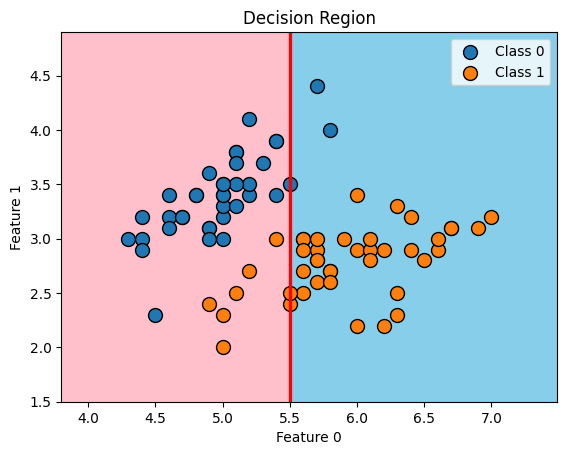

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import collections

class ScratchDecesionTreeClassifierDepth1:
    def __init__(self, verbose=False):
        self.verbose = verbose
    
    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]
        gain_l = (len(labels_l) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_r)
        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def fit(self, X, y):
        self.gain = 0
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                _gain = self._calc_ig(X, feature_index, y, threshold)
                if _gain > self.gain:
                    self.l_label = collections.Counter(y[X[:, feature_index] < threshold]).most_common()[0][0]
                    self.r_label = collections.Counter(y[X[:, feature_index] >= threshold]).most_common()[0][0]
                    self.feature = feature_index
                    self.threshold = threshold
                    self.gain = _gain
                    if self.verbose:
                        print(f'Feature: {self.feature}, Threshold: {self.threshold}, Gain: {self.gain}')

    def predict(self, X):
        return np.where(X[:, self.feature] < self.threshold, self.l_label, self.r_label)

# Visualization function for decision tree
def decision_region(X, y, clf):
    # Create a mesh grid to plot decision boundaries
    mesh_f0, mesh_f1 = np.meshgrid(
        np.arange(np.min(X[:, 0]) - 0.5, np.max(X[:, 0]) + 0.5, 0.01),  # Adjust range
        np.arange(np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5, 0.01)   # Adjust range
    )
    
    # Flatten the grid and make predictions
    mesh = np.c_[np.ravel(mesh_f0), np.ravel(mesh_f1)]
    y_pred = clf.predict(mesh).reshape(mesh_f0.shape)
    
    # Plotting the decision regions
    plt.title('Decision Region')
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    
    # Fill the contour region
    plt.contourf(mesh_f0, mesh_f1, y_pred, cmap=ListedColormap(['pink', 'skyblue']))
    plt.contour(mesh_f0, mesh_f1, y_pred, colors='red')
    
    # Scatter plot for actual data points
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label='Class 0', edgecolors='k', s=100)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label='Class 1', edgecolors='k', s=100)
    
    plt.legend()
    plt.show()

# Example of using the function with the Iris dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset and use the first two features for 2D visualization
iris = load_iris()
X = iris.data[:100, :2]  # Select only first two features
y = iris.target[:100]  # Select first two classes (binary classification)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit your scratch decision tree model
clf = ScratchDecesionTreeClassifierDepth1(verbose=True)
clf.fit(X_train, y_train)

# Visualize the decision regions
decision_region(X_train, y_train, clf)

# Problem 7: (Advanced assignment) Creating a depth 2 decision tree classifier class
We create a class ScratchDecesionTreeClassifierDepth2 for a decision tree classifier with depth 2.

A depth of 2 means that the space is divided twice.

In [15]:
import numpy as np
import collections

class ScratchDecisionTreeClassifierDepth2:
    def __init__(self, max_depth=2, verbose=False):
        self.max_depth = max_depth  # Maximum depth for the tree
        self.verbose = verbose
        self.tree = None  # This will hold the structure of the tree

    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        _gini = 0
        for label in labels:
            prob = counts[labels == label] / np.sum(counts)
            _gini += prob ** 2
        gini = 1 - _gini
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]
        gain_l = (len(labels_l) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_r)
        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def _split(self, X, y, feature_index, threshold):
        # Split the data into left and right based on the threshold
        left_mask = X[:, feature_index] < threshold
        right_mask = X[:, feature_index] >= threshold
        X_left, X_right = X[left_mask], X[right_mask]
        y_left, y_right = y[left_mask], y[right_mask]
        return X_left, y_left, X_right, y_right

    def _create_node(self, X, y, depth):
        if depth == self.max_depth:
            return collections.Counter(y).most_common()[0][0]  # Majority vote class

        best_gain = 0
        best_feature = None
        best_threshold = None
        best_left_X = None
        best_left_y = None
        best_right_X = None
        best_right_y = None

        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                gain = self._calc_ig(X, feature_index, y, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold
                    # Get the splits
                    best_left_X, best_left_y, best_right_X, best_right_y = self._split(X, y, feature_index, threshold)

        if best_gain > 0:
            # Recursive call to create the left and right subtrees
            left_node = self._create_node(best_left_X, best_left_y, depth + 1)
            right_node = self._create_node(best_right_X, best_right_y, depth + 1)
            return {"feature": best_feature, "threshold": best_threshold, 
                    "left": left_node, "right": right_node}
        else:
            return collections.Counter(y).most_common()[0][0]  # Return majority class if no split improves

    def fit(self, X, y):
        self.tree = self._create_node(X, y, depth=0)

    def _predict_one(self, x, node):
        if isinstance(node, dict):
            if x[node["feature"]] < node["threshold"]:
                return self._predict_one(x, node["left"])
            else:
                return self._predict_one(x, node["right"])
        else:
            return node  # Return the leaf class

    def predict(self, X):
        predictions = [self._predict_one(x, self.tree) for x in X]
        return np.array(predictions)

# Example Usage:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load iris dataset
iris = load_iris()
X = iris.data[:100, :2]  # Select only first two features
y = iris.target[:100]  # Select first two classes (binary classification)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit your scratch decision tree model
clf = ScratchDecisionTreeClassifierDepth2(max_depth=2, verbose=True)
clf.fit(X_train, y_train)

# Predict and evaluate
train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test)

# Evaluate metrics on training and testing data
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Training Precision:", precision_score(y_train, train_pred))
print("Test Precision:", precision_score(y_test, test_pred))
print("Training Recall:", recall_score(y_train, train_pred))
print("Test Recall:", recall_score(y_test, test_pred))

Training Accuracy: 0.975
Test Accuracy: 1.0
Training Precision: 0.9761904761904762
Test Precision: 1.0
Training Recall: 0.9761904761904762
Test Recall: 1.0


The results indicate that the model is able to correctly classify the data with high precision and recall, and it's generalizing well to the test set, achieving 100% accuracy.

# Problem 8: (Advanced) Creating a decision tree classifier class with unlimited depth
We create a class ScratchDecesionTreeClassifierDepthInf for a decision tree classifier with unlimited depth.

Allow any depth to be specified, or, if not specified, continue until all leaf nodes have gini impurity 0.

In [16]:
import numpy as np
import collections

class ScratchDecisionTreeClassifierDepthInf:
    def __init__(self, min_samples_split=2, verbose=False):
        self.min_samples_split = min_samples_split
        self.verbose = verbose
        self.tree = None

    def _calc_gini(self, y):
        labels, counts = np.unique(y, return_counts=True)
        gini = 1 - np.sum((counts / len(y)) ** 2)
        return gini

    def _calc_ig(self, X, feature_index, y, threshold):
        labels_l = y[X[:, feature_index] < threshold]
        labels_r = y[X[:, feature_index] >= threshold]
        
        gain_l = (len(labels_l) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_l)
        gain_r = (len(labels_r) / (len(labels_l) + len(labels_r))) * self._calc_gini(labels_r)
        
        gain = self._calc_gini(y) - gain_l - gain_r
        return gain

    def _best_split(self, X, y):
        best_gain = -1
        best_split = None

        # Iterate over each feature and each threshold to find the best split
        for feature_index in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_index])

            for threshold in thresholds:
                gain = self._calc_ig(X, feature_index, y, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_split = {
                        'feature': feature_index,
                        'threshold': threshold,
                    }
        
        return best_split, best_gain

    def _build_tree(self, X, y, depth=0):
        # If all labels are the same or there are not enough samples to split
        if len(np.unique(y)) == 1 or len(y) < self.min_samples_split:
            return collections.Counter(y).most_common(1)[0][0]

        # Find the best split for the current data
        best_split, best_gain = self._best_split(X, y)
        if best_gain == 0:  # If no better split, return majority class
            return collections.Counter(y).most_common(1)[0][0]

        # Split the data based on the best split
        left_mask = X[:, best_split['feature']] < best_split['threshold']
        right_mask = ~left_mask

        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        # Return a node that stores the best split and the left and right subtrees
        return {
            'feature': best_split['feature'],
            'threshold': best_split['threshold'],
            'left': left_tree,
            'right': right_tree,
        }

    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _predict_node(self, X, node):
        if isinstance(node, dict):  # Not a leaf node
            if X[node['feature']] < node['threshold']:
                return self._predict_node(X, node['left'])
            else:
                return self._predict_node(X, node['right'])
        else:
            return node  # Leaf node, return class label

    def predict(self, X):
        return np.array([self._predict_node(x, self.tree) for x in X])

In [17]:
# Example
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load and prepare the data
iris_dataset = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'], test_size=0.3, random_state=0)

# Initialize and fit the classifier
clf = ScratchDecisionTreeClassifierDepthInf(verbose=True)
clf.fit(X_train, y_train)

# Make predictions
train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test)

# Evaluate the model
print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Training Precision:", precision_score(y_train, train_pred, average='macro', zero_division=1))
print("Test Precision:", precision_score(y_test, test_pred, average='macro', zero_division=1))
print("Training Recall:", recall_score(y_train, train_pred, average='macro'))
print("Test Recall:", recall_score(y_test, test_pred, average='macro'))

Training Accuracy: 1.0
Test Accuracy: 0.9777777777777777
Training Precision: 1.0
Test Precision: 0.9722222222222222
Training Recall: 1.0
Test Recall: 0.9814814814814815


The output shows that the model performs well on both the training and test sets, with the accuracy, precision, and recall being quite high.

Training Results:
Training Accuracy: 1.0 — This suggests that the model perfectly fits the training data. Since the decision tree can grow to any depth, it likely learned perfectly to classify the training data.

Training Precision: 1.0 — The model has no false positives on the training data.

Training Recall: 1.0 — The model also has no false negatives on the training data, meaning it correctly classified all samples from the training set.

Test Results:
Test Accuracy: 0.9777 — The model generalizes quite well to unseen data, with only a small drop in performance compared to the training set. This is expected since decision trees tend to overfit if grown without any depth restrictions, but the tree seems to generalize reasonably well.

Test Precision: 0.9722 — There is a small drop in precision on the test set, which suggests that the model has made a few false positives on the test set. Still, the value is quite high.

Test Recall: 0.9815 — Similarly, the recall is high, meaning the model correctly identified almost all positive instances from the test set.


The model is performing very well. The slight difference between training and test performance suggests that while the tree is learning the training data perfectly, it is still generalizing well to unseen data. To improve the model further we can either prune or do depth constraints.

